
## 1) Dependências e ambiente


In [1]:
!pip install -q tensorflow scikit-learn matplotlib numpy


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [2]:


import sys, os, math, json, random, itertools
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

print("Versões:")
print("Python:", sys.version)
print("TensorFlow:", tf.__version__)


2025-08-22 04:18:35.182283: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-22 04:18:38.592057: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-22 04:18:40.818137: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755836323.529530    3994 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755836324.136145    3994 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755836329.580371    3994 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Versões:
Python: 3.12.1 (main, Jul 10 2025, 11:57:50) [GCC 13.3.0]
TensorFlow: 2.19.0


In [3]:

# Carregar Fashion MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalização [0,1] e reshape para canal único
x_train = (x_train.astype("float32") / 255.0)[..., np.newaxis]
x_test  = (x_test.astype("float32")  / 255.0)[..., np.newaxis]

# Mapeamento para binário
cold = {1, 2, 4, 9}
hot  = {0, 3, 5, 6, 7, 8}

def map_label(y):
    return np.array([0 if cls in cold else 1 for cls in y], dtype=np.int32)

y_train_bin = map_label(y_train)
y_test_bin  = map_label(y_test)

# Split validação
x_train, x_val, y_train_bin, y_val_bin = train_test_split(
    x_train, y_train_bin, test_size=0.1, random_state=42, stratify=y_train_bin
)

x_train.shape, x_val.shape, x_test.shape, y_train_bin.shape, y_val_bin.shape, y_test_bin.shape


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((54000, 28, 28, 1),
 (6000, 28, 28, 1),
 (10000, 28, 28, 1),
 (54000,),
 (6000,),
 (10000,))


## 3) Visualização rápida


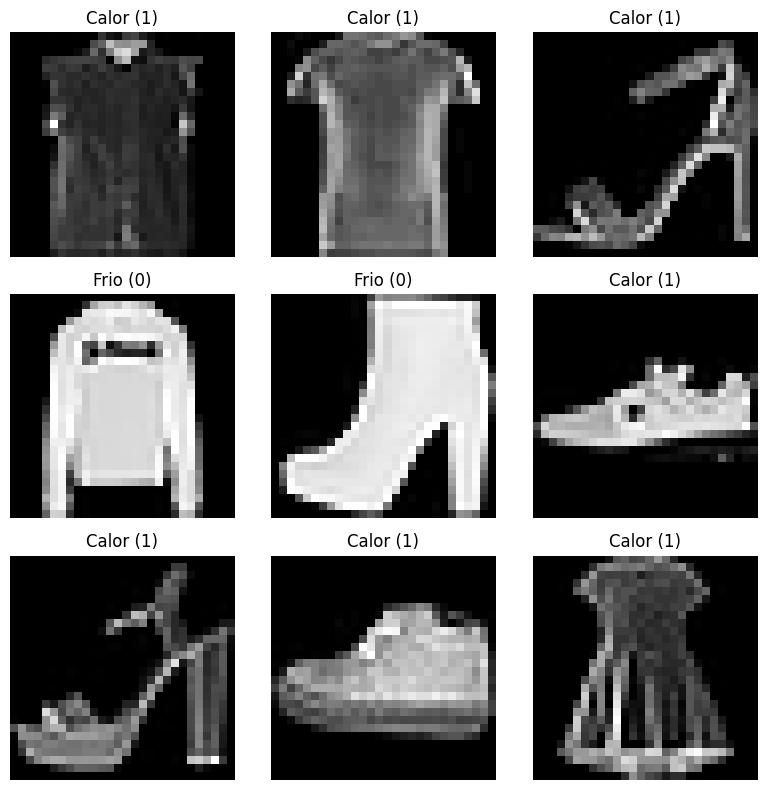

In [4]:

# Visualizar algumas amostras com seus rótulos binários
class_names = ["Frio (0)", "Calor (1)"]
plt.figure(figsize=(8, 8))
for i in range(9):
    idx = np.random.randint(0, x_train.shape[0])
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[idx].squeeze(), cmap="gray")
    plt.title(class_names[y_train_bin[idx]])
    plt.axis("off")
plt.tight_layout()
plt.show()



## 4) Data augmentation (opcional) e *pipeline* de dados


In [5]:

# Camada de augmentation leve
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomZoom(0.05),
], name="augmentation")


2025-08-22 04:19:11.409744: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



## 5) Arquitetura da CNN


In [6]:

def build_model(input_shape=(28, 28, 1)):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)  # binário
    
    model = keras.Model(inputs, outputs, name="cnn_fashionmnist_frio_calor")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )
    return model

model = build_model()
model.summary()


Model: "cnn_fashionmnist_frio_calor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,889 (398.00 KB)

 Trainable params: 101,441 (396.25 KB)

 Non-trainable params: 448 (1.75 KB)


## 6) Treinamento


In [7]:

callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss"),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
]

history = model.fit(
    x_train, y_train_bin,
    validation_data=(x_val, y_val_bin),
    epochs=15,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/15


2025-08-22 04:19:11.779168: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 169344000 exceeds 10% of free system memory.


422/422 ━━━━━━━━━━━━━━━━━━━━ 64s 143ms/step - accuracy: 0.8457 - auc: 0.9200 - loss: 0.3381 - val_accuracy: 0.7513 - val_auc: 0.8793 - val_loss: 0.5048 - learning_rate: 0.0010
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 61s 144ms/step - accuracy: 0.9168 - auc: 0.9741 - loss: 0.2015 - val_accuracy: 0.9153 - val_auc: 0.9725 - val_loss: 0.2268 - learning_rate: 0.0010
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 146ms/step - accuracy: 0.9230 - auc: 0.9783 - loss: 0.1842 - val_accuracy: 0.9197 - val_auc: 0.9801 - val_loss: 0.2095 - learning_rate: 0.0010
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 146ms/step - accuracy: 0.9306 - auc: 0.9814 - loss: 0.1699 - val_accuracy: 0.9267 - val_auc: 0.9801 - val_loss: 0.1866 - learning_rate: 0.0010
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 147ms/step - accuracy: 0.9333 - auc: 0.9828 - loss: 0.1630 - val_accuracy: 0.9252 - val_auc: 0.9817 - val_loss: 0.1880 - learning_rate: 0.0010
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.9366 - a


## 7) Curvas de aprendizado


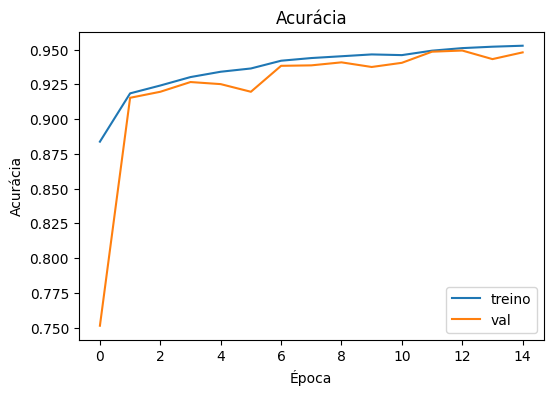

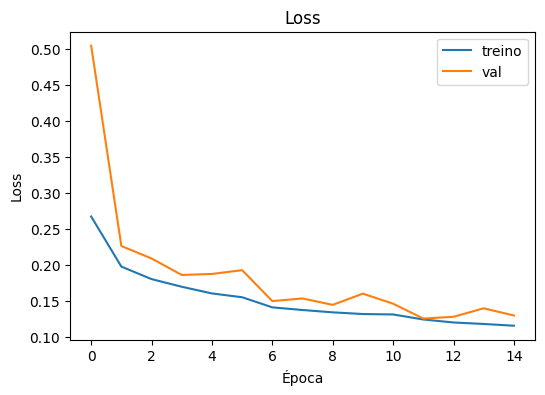

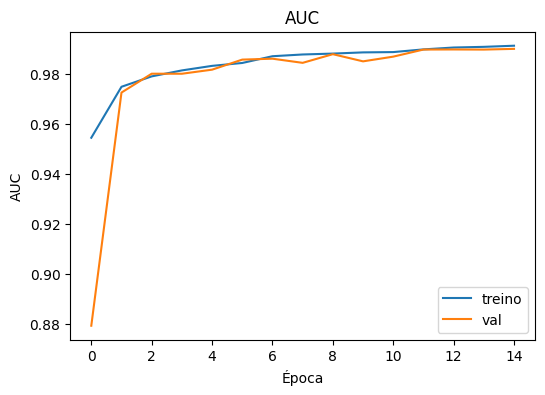

In [8]:

def plot_history(h):
    # Acurácia
    plt.figure(figsize=(6,4))
    plt.plot(h.history["accuracy"], label="treino")
    plt.plot(h.history["val_accuracy"], label="val")
    plt.title("Acurácia")
    plt.xlabel("Época")
    plt.ylabel("Acurácia")
    plt.legend()
    plt.show()

    # Loss
    plt.figure(figsize=(6,4))
    plt.plot(h.history["loss"], label="treino")
    plt.plot(h.history["val_loss"], label="val")
    plt.title("Loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # AUC
    if "auc" in h.history:
        plt.figure(figsize=(6,4))
        plt.plot(h.history["auc"], label="treino")
        plt.plot(h.history["val_auc"], label="val")
        plt.title("AUC")
        plt.xlabel("Época")
        plt.ylabel("AUC")
        plt.legend()
        plt.show()

plot_history(history)



## 8) Avaliação no *test set* + Métricas


2025-08-22 04:37:33.787225: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.


Avaliação — Loss: 0.1298 | Acc: 0.9471 | AUC: 0.9889


2025-08-22 04:37:36.996129: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 31360000 exceeds 10% of free system memory.



Classification Report:

              precision    recall  f1-score   support

    Frio (0)       0.93      0.94      0.93      4000
   Calor (1)       0.96      0.95      0.96      6000

    accuracy                           0.95     10000
   macro avg       0.94      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



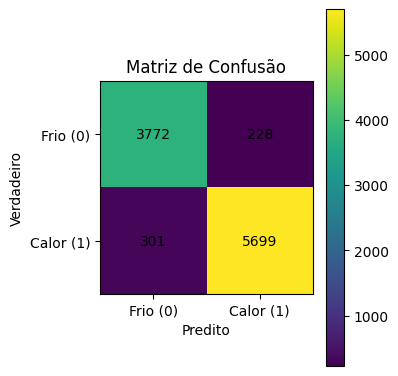

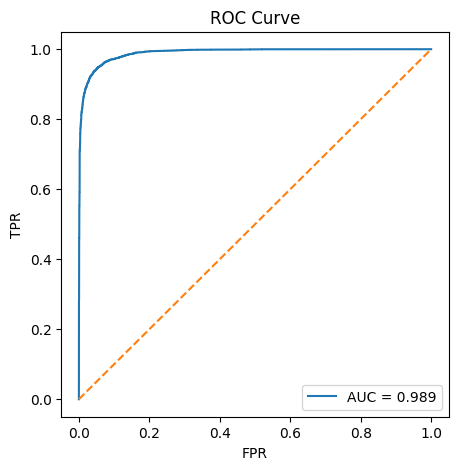

In [9]:

test_loss, test_acc, test_auc = model.evaluate(x_test, y_test_bin, verbose=0)
print(f"Avaliação — Loss: {test_loss:.4f} | Acc: {test_acc:.4f} | AUC: {test_auc:.4f}")

# Predições
y_prob = model.predict(x_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Relatório e matriz de confusão
print("\nClassification Report:\n")
print(classification_report(y_test_bin, y_pred, target_names=["Frio (0)", "Calor (1)"]))

cm = confusion_matrix(y_test_bin, y_pred)
plt.figure(figsize=(4,4))
plt.imshow(cm, interpolation="nearest")
plt.title("Matriz de Confusão")
plt.xticks([0,1], ["Frio (0)", "Calor (1)"])
plt.yticks([0,1], ["Frio (0)", "Calor (1)"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predito")
plt.ylabel("Verdadeiro")
plt.colorbar()
plt.tight_layout()
plt.show()

# Curva ROC
fpr, tpr, thr = roc_curve(y_test_bin, y_prob)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test_bin, y_prob):.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()



## 9) Salvar o modelo (opcional)


In [10]:

# Salvar modelo treinado
model.save("cnn_fashion_frio_calor.keras")
print("Modelo salvo em cnn_fashion_frio_calor.keras")


Modelo salvo em cnn_fashion_frio_calor.keras
